## Example with significance

The `SignificanceDecorator` enhances PySubgroup by adding **statistical significance** testing (via permutation tests) to subgroup discovery. 

1. Wrap your search strategy (e.g., `BeamSearch()`) with `SignificanceDecorator`
2. Results include **p-values** and **adjusted p-values** (via `result.to_dataframe()`). **Z-scores** only if *normality* is passed.

In [1]:
import pysubgroup as ps
from pysubgroup.datasets import get_titanic_data

data = get_titanic_data() 

task = ps.SubgroupDiscoveryTask(
    data,
    ps.BinaryTarget("Survived", True),
    ps.create_selectors(data, ignore=["Survived", "Name", "Ticket"]),
    result_set_size=5,
    depth=2,
    qf=ps.StandardQF(0.5)
)

wrapper = ps.SignificanceDecorator(ps.BeamSearch(), num_permutations=1000)
result = wrapper.execute(task)
result.to_dataframe()


Generating null distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift,p_value,p_value_adj
0,0.220564,Sex=='female',56,156,40,54,100,0.358974,0.641026,0.740741,0.259259,0.714286,0.140000,0.346154,2.063492,0.000999,0.004995
1,0.197697,Sex=='female' AND SibSp: [0:1[,25,156,21,54,131,0.160256,0.839744,0.388889,0.611111,0.840000,0.251908,0.346154,2.426667,0.000999,0.004995
2,0.197658,Parch==0 AND Sex=='female',41,156,30,54,115,0.262821,0.737179,0.555556,0.444444,0.731707,0.208696,0.346154,2.113821,0.000999,0.004995
3,0.158232,Pclass==2 AND Sex=='female',12,156,11,54,144,0.076923,0.923077,0.203704,0.796296,0.916667,0.298611,0.346154,2.648148,0.004995,0.009990
4,0.157049,Pclass==1 AND Sex=='female',9,156,9,54,147,0.057692,0.942308,0.166667,0.833333,1.000000,0.306122,0.346154,2.888889,0.004995,0.009990


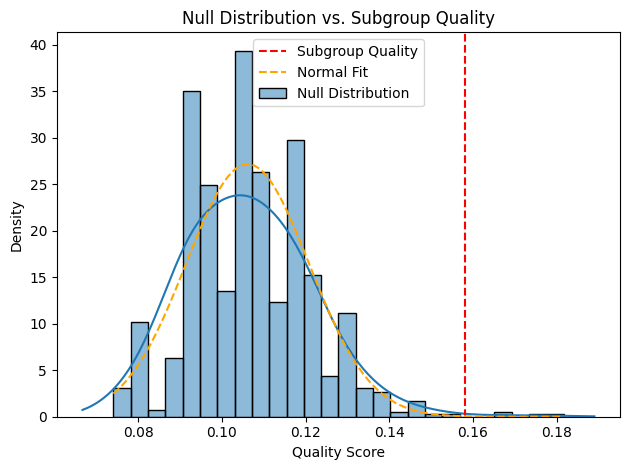

In [2]:
ps.plot_null_distribution(
    wrapper.null_distribution, # Null distribution
    result.results[3][0],   # Quality of the subgroup at idx 3
    bw_adjust=2,            # Increase smoothness of the KDE (optional, default=1)
    compare_gumbel=False,   # Compare with Gumbel distribution
    compare_normal=True,    # Compare with Normal distribution (CLT)
)

In [3]:
import pysubgroup as ps
from pysubgroup.datasets import get_credit_data

data2 = get_credit_data()
data2 = data2.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

task2 = ps.SubgroupDiscoveryTask(
    data2, 
    ps.NumericTarget("credit_amount"), 
    ps.create_selectors(data2, ignore=["credit_amount"]), 
    result_set_size=10, 
    depth=2, 
    qf=ps.StandardQFNumeric(1.0)
)

wrapper2 = ps.SignificanceDecorator(ps.BeamSearch(), num_permutations=1000)
result2 = wrapper2.execute(task2)
result2.to_dataframe()

Generating null distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

,quality,subgroup,size_sg,size_dataset,mean_sg,mean_dataset,std_sg,std_dataset,median_sg,median_dataset,max_sg,max_dataset,min_sg,min_dataset,mean_lift,median_lift,p_value,p_value_adj
0,639577.046,duration>=30.0,213,1000,6273.967136,3271.258,3477.406285,2821.325155,5771.0,2319.5,18424.0,18424.0,909.0,250.0,1.917907,2.488036,0.000999,0.00999
1,624424.304,duration>=30.0 AND foreign_worker=='yes',212,1000,6216.655660,3271.258,3383.751315,2821.325155,5756.5,2319.5,15945.0,18424.0,909.0,250.0,1.900387,2.481785,0.000999,0.00999
2,579219.206,duration>=30.0 AND other_parties=='none',193,1000,6272.393782,3271.258,3474.426664,2821.325155,5771.0,2319.5,18424.0,18424.0,909.0,250.0,1.917426,2.488036,0.000999,0.00999
3,547252.302,duration>=30.0 AND num_dependents==1.0,181,1000,6294.751381,3271.258,3570.855045,2821.325155,5771.0,2319.5,18424.0,18424.0,909.0,250.0,1.924260,2.488036,0.000999,0.00999
4,490633.140,duration>=30.0 AND other_payment_plans=='none',170,1000,6157.335294,3271.258,3379.400370,2821.325155,5653.0,2319.5,15945.0,18424.0,909.0,250.0,1.882253,2.437163,0.000999,0.00999
5,430086.138,duration>=30.0 AND personal_status=='male single',139,1000,6365.402878,3271.258,3565.898334,2821.325155,5842.0,2319.5,15945.0,18424.0,909.0,250.0,1.945858,2.518646,0.000999,0.00999
6,426708.426,duration>=30.0 AND own_telephone=='yes',103,1000,7414.058252,3271.258,3917.576980,2821.325155,6948.0,2319.5,18424.0,18424.0,1819.0,250.0,2.266424,2.995473,0.000999,0.00999
7,391185.686,duration>=30.0 AND existing_credits==1.0,133,1000,6212.503759,3271.258,3699.045865,2821.325155,5179.0,2319.5,18424.0,18424.0,909.0,250.0,1.899118,2.232809,0.000999,0.00999
8,385277.848,duration>=30.0 AND housing=='own',144,1000,5946.798611,3271.258,3438.234741,2821.325155,4864.0,2319.5,18424.0,18424.0,909.0,250.0,1.817893,2.097004,0.000999,0.00999
9,383476.768,own_telephone=='yes',404,1000,4220.457921,3271.258,3439.485907,2821.325155,3020.0,2319.5,18424.0,18424.0,385.0,250.0,1.290164,1.302005,0.000999,0.00999


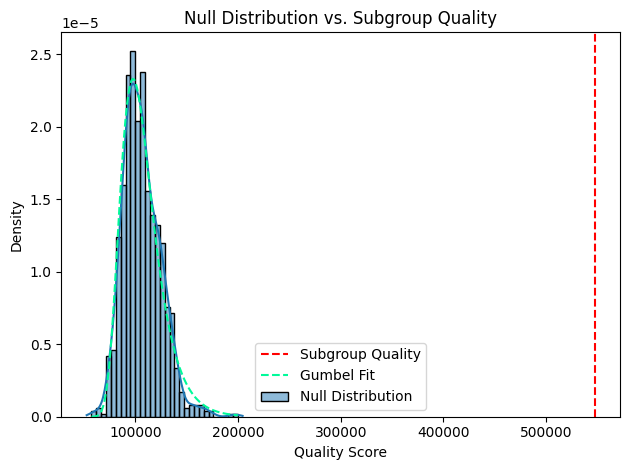

In [4]:
ps.plot_null_distribution(
    wrapper2.null_distribution, # Null distribution
    result2.results[3][0],  # Quality of the subgroup at idx 3
    bw_adjust=1,            # Increase smoothness of the KDE (optional, default=1)
    compare_gumbel=True,    # Compare with Gumbel distribution
    compare_normal=False,   # Compare with Normal distribution (CLT)
)